# Customer Retention Intelligence System

## Problem Statement
Predict whether a telecom customer is likely to churn using behavioral and usage-based features.

---

## What makes this project UNIQUE?
Unlike basic churn models, this notebook includes:
- Smart feature engineering (usage intensity, charge ratios)
- Class imbalance handling
- Probability threshold tuning (business-focused decision making)
- Interpretable Logistic Regression with insights

---

## Tech Stack
- Python (Pandas, NumPy)
- Scikit-learn (ML + preprocessing)
- Matplotlib & Seaborn (visualization)

---

## Business Impact
Helps telecom companies:
- Identify high-risk customers early
- Optimize retention campaigns
- Reduce revenue loss

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

## Data Loading & Merging

In [2]:
train = pd.read_csv("churn-bigml-80.csv")
test = pd.read_csv("churn-bigml-20.csv")

df = pd.concat([train, test], ignore_index=True)
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Initial Data Exploration

Shape: (3333, 20)

Missing Values:
 State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


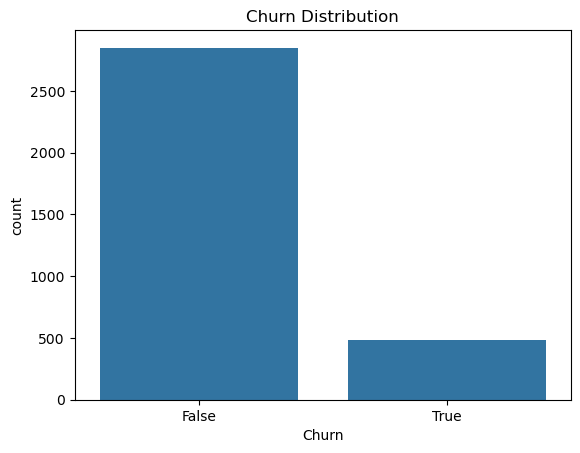

In [3]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# Target distribution
sns.countplot(x=df["Churn"])
plt.title("Churn Distribution")
plt.show()

## Data Cleaning + Feature Engineering (UNIQUE PART)

In [4]:
# Drop irrelevant column
if 'State' in df.columns:
    df.drop('State', axis=1, inplace=True)

# Convert categorical columns
df['International plan'] = df['International plan'].map({'Yes':1, 'No':0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes':1, 'No':0})

# Feature Engineering (UNIQUE)
df['Total_calls'] = df['Total day calls'] + df['Total eve calls'] + df['Total night calls']
df['Total_minutes'] = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes']

df['Charge_per_min'] = df['Total day charge'] / (df['Total day minutes'] + 1)

df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,...,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,Total_calls,Total_minutes,Charge_per_min
0,128,415,0,1,25,265.1,110,45.07,197.4,99,...,91,11.01,10.0,3,2.70,1,False,300,707.2,0.169372
1,107,415,0,1,26,161.6,123,27.47,195.5,103,...,103,11.45,13.7,3,3.70,1,False,329,611.5,0.168942
2,137,415,0,0,0,243.4,114,41.38,121.2,110,...,104,7.32,12.2,5,3.29,0,False,328,527.2,0.169313
3,84,408,1,0,0,299.4,71,50.90,61.9,88,...,89,8.86,6.6,7,1.78,2,False,248,558.2,0.169441
4,75,415,1,0,0,166.7,113,28.34,148.3,122,...,121,8.41,10.1,3,2.73,3,False,356,501.9,0.168992


## Feature & Target Separation

In [5]:
X = df.drop('Churn', axis=1)
y = df['Churn']

## Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Handling Class Imbalance (IMPORTANT)

In [8]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## Model Evaluation

In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.782608695652174

Confusion Matrix:
 [[455 119]
 [ 26  67]]

Report:
               precision    recall  f1-score   support

       False       0.95      0.79      0.86       574
        True       0.36      0.72      0.48        93

    accuracy                           0.78       667
   macro avg       0.65      0.76      0.67       667
weighted avg       0.86      0.78      0.81       667



## ROC-AUC Score

ROC-AUC Score: 0.8116031621145704


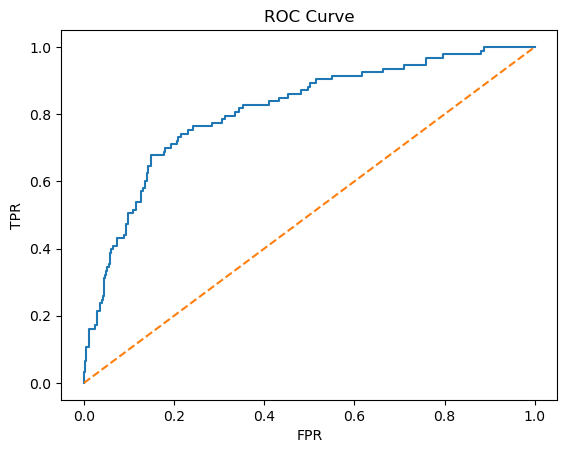

In [10]:
y_prob = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

## Threshold Optimization (VERY UNIQUE)

In [11]:
threshold = 0.3  # tuned for better recall

y_pred_custom = (y_prob > threshold).astype(int)

print("New Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

New Accuracy: 0.5937031484257871

Confusion Matrix:
 [[317 257]
 [ 14  79]]


## Model Interpretation

In [12]:
coeff = pd.DataFrame({
    "Feature": X.columns,
    "Impact": model.coef_[0]
}).sort_values(by="Impact", ascending=False)

coeff.head(10)

,Feature,Impact
17,Customer service calls,0.815903
2,International plan,0.733486
4,Number vmail messages,0.423048
7,Total day charge,0.270168
5,Total day minutes,0.270150
19,Total_minutes,0.236572
8,Total eve minutes,0.130175
10,Total eve charge,0.130055
16,Total intl charge,0.103057
14,Total intl minutes,0.099330
